<a href="https://www.kaggle.com/code/adegbaju/chess-opening-gameplay-v2-llm-chess-analysis?scriptVersionId=302490679" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 🧠 Chess Opening Gameplay V2 – LLM Chess Analysis

# Import libraries

In [1]:
!pip install python-chess

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 74.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for chess: filename=chess-1.11.2-py3-none-any.whl size=147775 sha256=8f829a45326e3946db66d5e24d8b0e8de36492574861de3c59f26612bfc4e083
  Stored in directory: /root/.cache/pip/wheels/83/1f/4e/8f4300f7dd554eb8de70ddfed96e94d3d030ace10c5b53d447
Successfully built chess


In [2]:
import chess
import chess.pgn
import glob
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

# For progress tracking
from tqdm import tqdm

board = chess.Board()
print(board)

r n b q k b n r
p p p p p p p p
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
P P P P P P P P
R N B Q K B N R


# Load dataset

In [3]:
# Path to dataset (after adding)
data_path = '/kaggle/input/datasets/organizations/kaggle/chess-opening-gameplay-v2'

# Get all PGN files
pgn_files = glob.glob(os.path.join(data_path, '*.pgn'))
print(f"Found {len(pgn_files)} PGN files.")

Found 2200 PGN files.


# Helper function to parse a PGN file with reasoning


In [4]:
def parse_pgn(file_path):
    """Parse a PGN file and return a dictionary with game info and moves with reasoning."""
    with open(file_path) as f:
        game = chess.pgn.read_game(f)
    
    if game is None:
        return None
    
    # Extract headers
    headers = dict(game.headers)
    
    # Extract moves and comments
    moves_with_comments = []
    node = game
    while node.variations:
        next_node = node.variation(0)
        move = node.board().san(next_node.move)
        comment = next_node.comment.strip() if next_node.comment else ""
        # Remove nested thinking tags if present
        # (some comments have <think>...</think>)
        if comment:
            # Try to extract the part after "thoughts]" if any
            if ']' in comment:
                comment = comment.split(']', 1)[-1].strip()
        moves_with_comments.append({
            'move_number': len(moves_with_comments) + 1,
            'move': move,
            'comment': comment,
            'comment_length': len(comment)
        })
        node = next_node
    
    return {
        'headers': headers,
        'moves': moves_with_comments,
        'result': headers.get('Result', '*'),
        'white': headers.get('White', '?'),
        'black': headers.get('Black', '?'),
        'fen': headers.get('FEN', None)
    }

# Process all files

In [5]:
games_data = []
failed = 0

for file in tqdm(pgn_files[:100]):  # Process first 100 for speed; remove slice to process all
    game_dict = parse_pgn(file)
    if game_dict:
        games_data.append(game_dict)
    else:
        failed += 1

print(f"Successfully parsed {len(games_data)} games. Failed: {failed}")

100%|██████████| 100/100 [00:04<00:00, 22.45it/s]

Successfully parsed 100 games. Failed: 0


# Create a DataFrame with game summaries

In [6]:
df_games = pd.DataFrame([
    {
        'white': g['white'],
        'black': g['black'],
        'result': g['result'],
        'num_moves': len(g['moves']),
        'avg_comment_len': sum(m['comment_length'] for m in g['moves']) / len(g['moves']) if g['moves'] else 0,
        'total_comment_len': sum(m['comment_length'] for m in g['moves']),
        'opening_fen': g['fen'],
        'first_move': g['moves'][0]['move'] if g['moves'] else None
    }
    for g in games_data
])

df_games.head()

,white,black,result,num_moves,avg_comment_len,total_comment_len,opening_fen,first_move
0,Claude Haiku 4.5,Grok 4,0-1,24,9712.000000,233088,rnbqkbnr/pppppp1p/6p1/8/4P3/8/PPPP1PPP/RNBQKBN...,d4
1,GPT-5.2,Gemini 3 Pro Preview,0-1,50,1164.160000,58208,rnbqkbnr/pppp1ppp/4p3/8/4P3/8/PPPP1PPP/RNBQKBN...,d4
2,Claude Sonnet 4.5,Grok 4.1 Fast Reasoning,0-1,64,7920.906250,506938,rnbqkb1r/pppppppp/5n2/8/3P4/8/PPP1PPPP/RNBQKBN...,c4
3,Grok 4.1 Fast Reasoning,GPT-5.2,1/2-1/2,135,916.000000,123660,rnbqkbnr/ppp1pppp/3p4/8/3P4/8/PPP1PPPP/RNBQKBN...,c4
4,GPT-5.2,GPT-5 mini,1-0,81,623.111111,50472,rnbqkbnr/ppp1pppp/3p4/8/3P4/8/PPP1PPPP/RNBQKBN...,e4


# Basic statistics

# Number of games per model pair

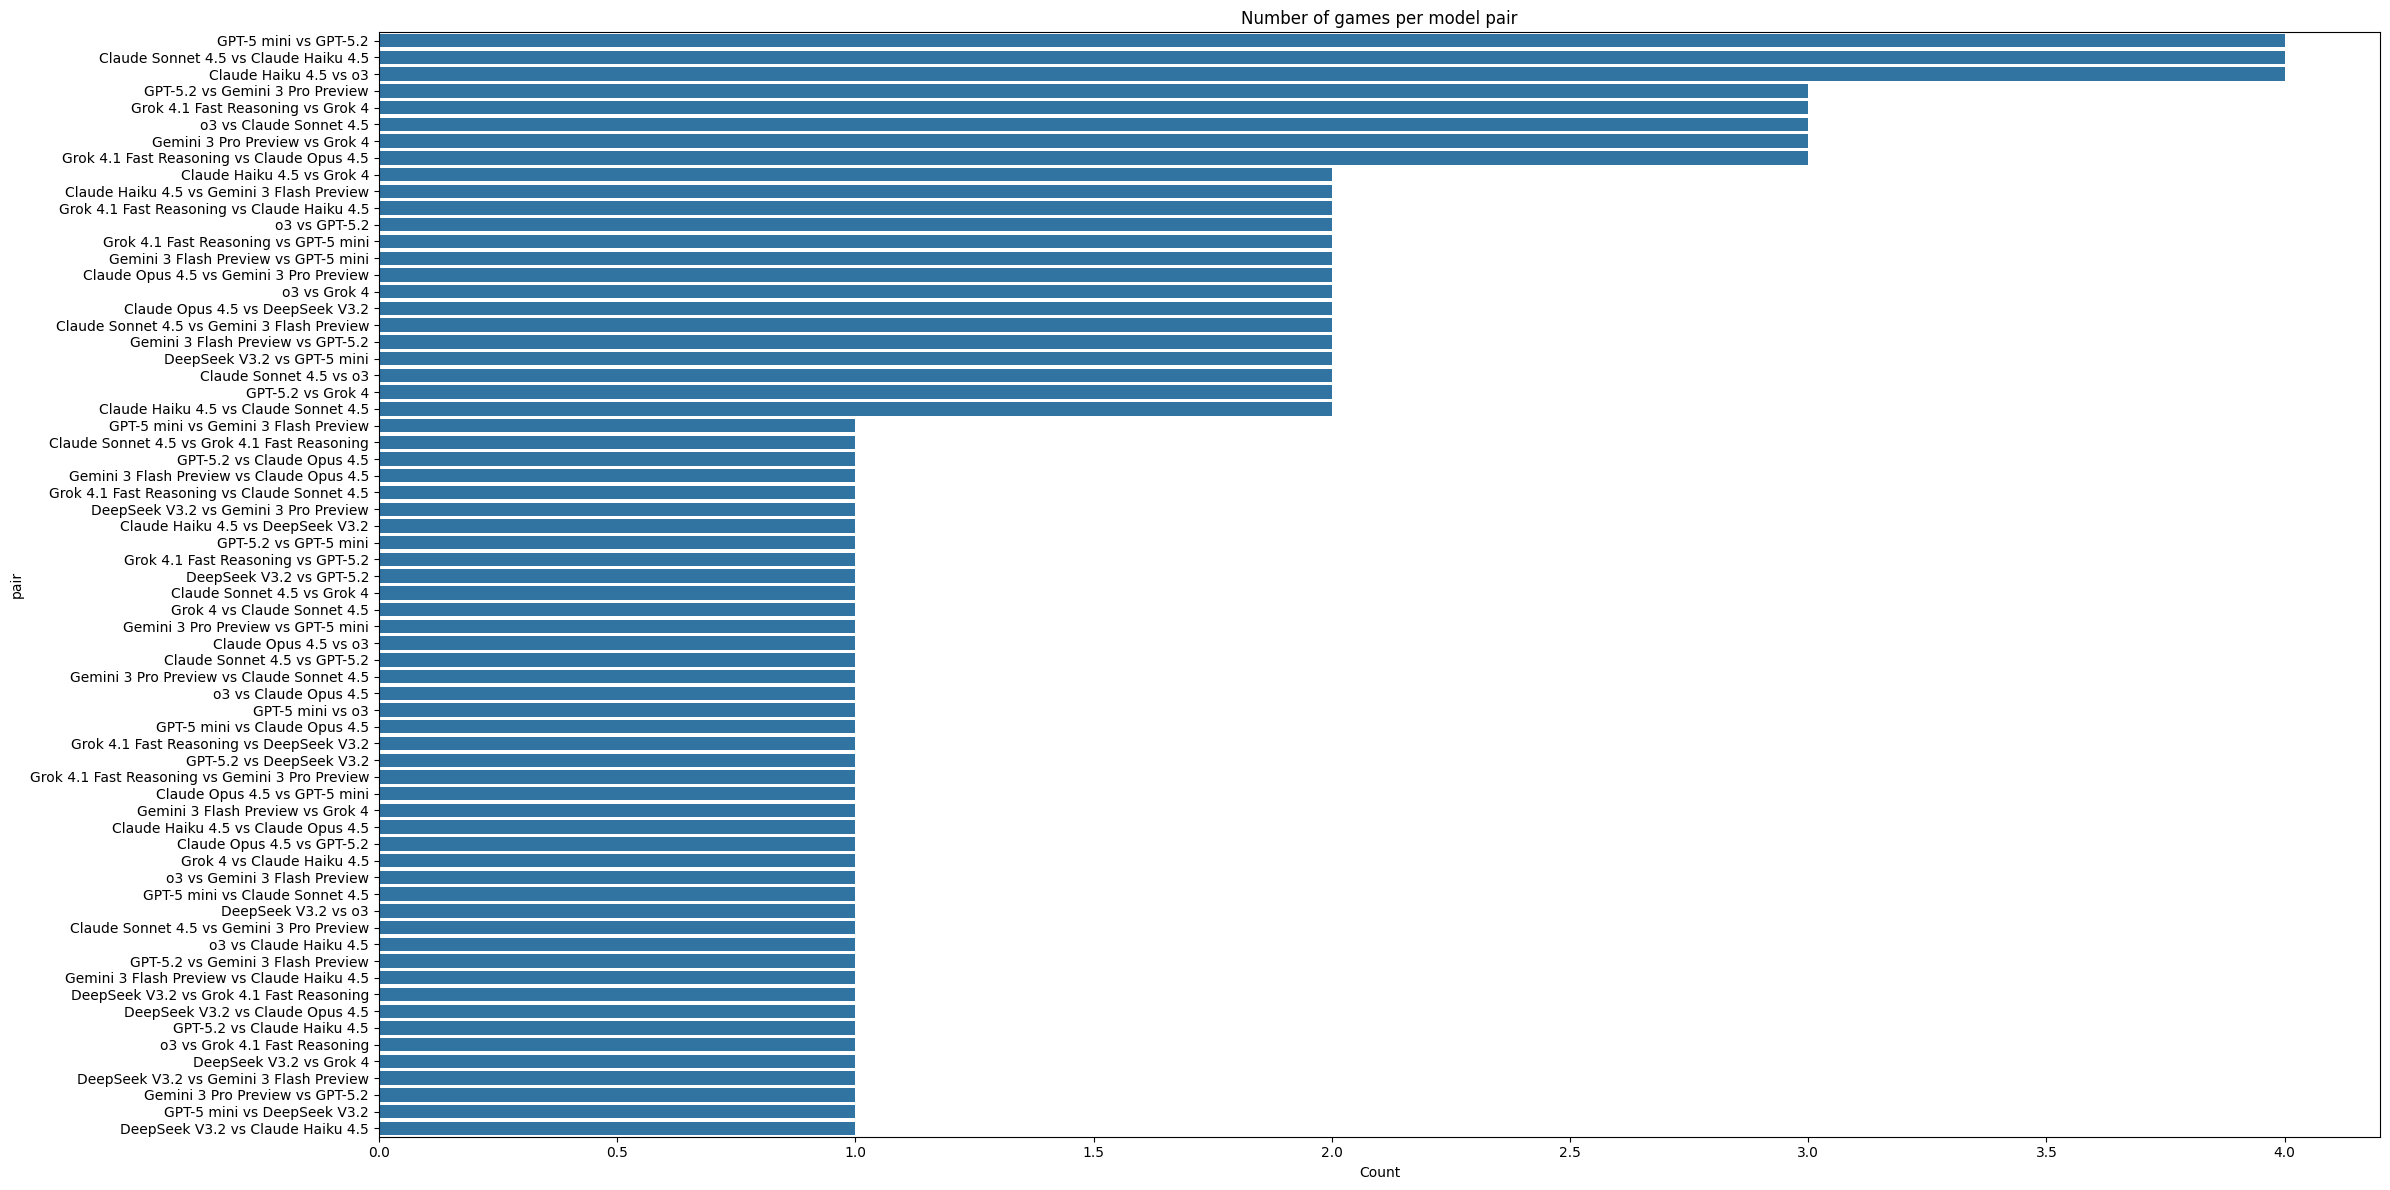

In [7]:
plt.figure(figsize=(24,12))
df_games['pair'] = df_games['white'] + ' vs ' + df_games['black']
sns.countplot(y='pair', data=df_games, order=df_games['pair'].value_counts().index)
plt.title('Number of games per model pair')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

# Game outcomes

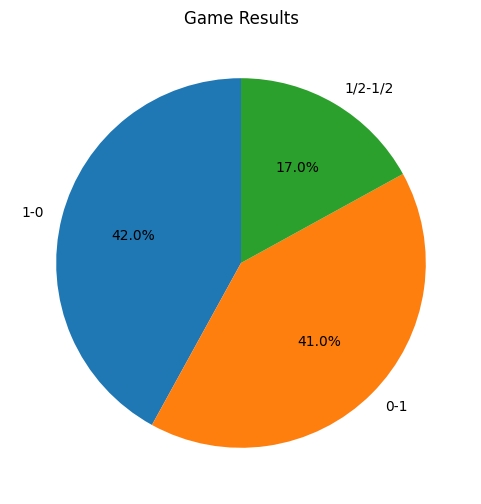

In [8]:
outcome_counts = df_games['result'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(outcome_counts.values, labels=outcome_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Game Results')
plt.show()

# Most common first moves (opening moves)

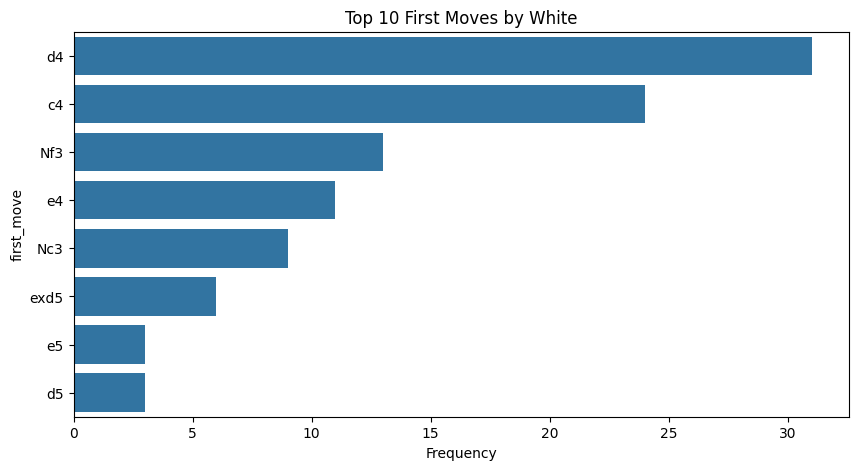

In [9]:
first_moves = df_games['first_move'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=first_moves.values, y=first_moves.index)
plt.title('Top 10 First Moves by White')
plt.xlabel('Frequency')
plt.show()

# Reasoning analysis

In [10]:
# Collect all comments
all_comments = []
for g in games_data:
    for m in g['moves']:
        if m['comment']:
            all_comments.append(m['comment'])

print(f"Total reasoning comments: {len(all_comments)}")

Total reasoning comments: 6492


# Average comment length per model (who is thinking)

In [11]:
def get_side_for_move(move_number):
    return 'white' if move_number % 2 == 1 else 'black'

# Build a list of (side, comment_length)
side_lengths = []
for g in games_data:
    for m in g['moves']:
        side = get_side_for_move(m['move_number'])
        side_lengths.append((side, m['comment_length']))

df_comments = pd.DataFrame(side_lengths, columns=['side', 'length'])

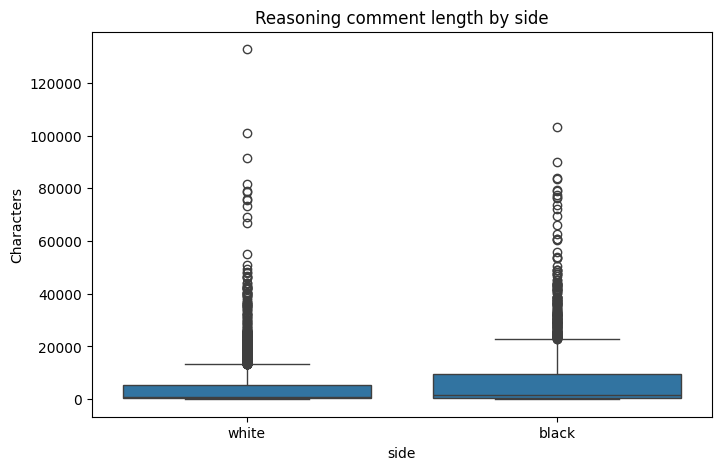

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x='side', y='length', data=df_comments)
plt.title('Reasoning comment length by side')
plt.ylabel('Characters')
plt.show()

# Most common words/phrases in reasoning

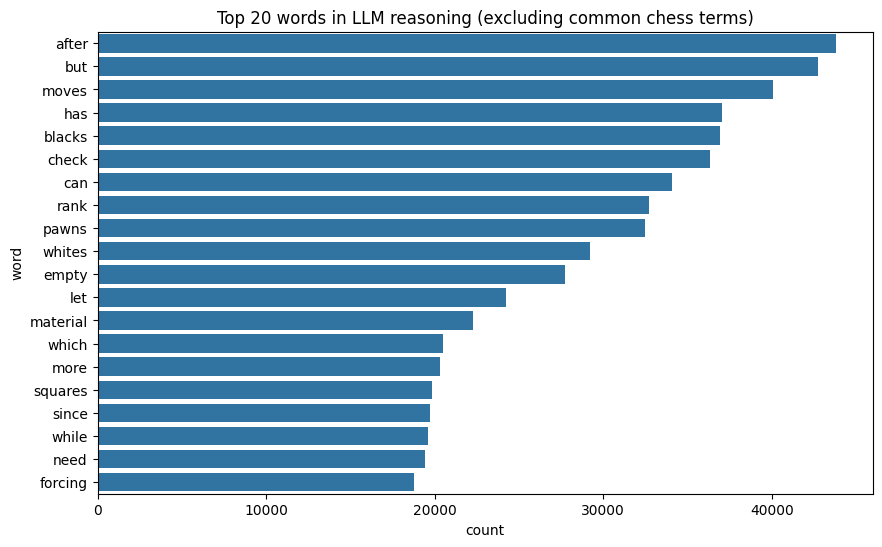

In [13]:
from collections import Counter
import re

def clean_comment(text):
    # Lowercase, remove punctuation
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text

all_text = ' '.join(all_comments)
words = clean_comment(all_text).split()
word_counts = Counter(words)

# Remove common chess terms and stopwords if desired
stopwords = {'the', 'and', 'to', 'a', 'of', 'in', 'that', 'is', 'for', 'on', 'with', 
             'this', 'i', 'it', 'as', 'be', 'are', 'from', 'at', 'or', 'have', 'an',
             'my', 'move', 'black', 'white', 'queen', 'king', 'pawn', 'knight',
             'bishop', 'rook', 'position', 'square', 'board', 'think'}

filtered_counts = {word: count for word, count in word_counts.items() if word not in stopwords and len(word) > 2}
top_words = Counter(filtered_counts).most_common(20)

words_df = pd.DataFrame(top_words, columns=['word', 'count'])
plt.figure(figsize=(10,6))
sns.barplot(x='count', y='word', data=words_df)
plt.title('Top 20 words in LLM reasoning (excluding common chess terms)')
plt.show()

#  Example game with reasoning

In [14]:
example = games_data[0]
print(f"Game: {example['white']} vs {example['black']} – Result: {example['result']}")
print("\nMoves with reasoning:\n")
for m in example['moves'][:10]:  # first 10 moves
    print(f"{m['move_number']:2}. {m['move']:6}  {m['comment'][:100]}..." if len(m['comment']) > 100 else f"{m['move_number']:2}. {m['move']:6}  {m['comment']}")

Game: Claude Haiku 4.5 vs Grok 4 – Result: 0-1

Moves with reasoning:

 1. d4      Final Answer: Bg7
 2. Bg7     <think>
Let me analyze the chess position from the given FEN: rnbqk1nr/ppppppbp/6p1/8/3PP3/8/PPP2PPP...
 3. Nc3     ### Step-by-Step Reasoning

1. **Understand the position**: The FEN represents the board after White...
 4. d6      <think>
Let me analyze the current board position from the FEN: rnbqk1nr/ppp1ppbp/3p2p1/8/3PP3/2N5/P...
 5. f4      Final Answer: Nf6
 6. Nf6     <think>
Let me analyze the current position from the FEN:
rnbqk2r/ppp1ppbp/3p1np1/8/3PPP2/2N5/PPP3PP...
 7. Nf3     ### Reasoning Step by Step

1. **Understand the position**: This is the Pirc Defense, Austrian Attac...
 8. O-O     <think>
Let me analyze the current position from the FEN: rnbq1rk1/ppp1ppbp/3p1np1/8/3PPP2/2N2N2/PPP...
 9. Bd3     ### Step-by-Step Reasoning:

1. **Understand the Position**: This is a Pirc Defense, Austrian Attack...
10. Na6     <think>
Let me analyze the current position f

# Save processed data

In [15]:
# Save DataFrame for later use
df_games.to_csv('chess_games_summary.csv', index=False)
df_comments.to_csv('comment_lengths.csv', index=False)

# Compare move choices against known opening databases

In [16]:
# Count games by starting FEN
fen_counts = df_games['opening_fen'].value_counts()
print(f"Number of distinct opening positions: {len(fen_counts)}")
print("\nTop 5 most frequent openings:")
print(fen_counts.head())

Number of distinct opening positions: 20

Top 5 most frequent openings:
opening_fen
rnbqkbnr/pppppp1p/6p1/8/3P4/8/PPP1PPPP/RNBQKBNR w KQkq - 0 2    9
rnbqkbnr/pppppp1p/6p1/8/4P3/8/PPPP1PPP/RNBQKBNR w KQkq - 0 2    8
rnbqkbnr/ppp1pppp/3p4/8/3P4/8/PPP1PPPP/RNBQKBNR w KQkq - 0 2    8
r1bqkbnr/pppppppp/2n5/8/4P3/8/PPPP1PPP/RNBQKBNR w KQkq - 1 2    7
rnbqkbnr/ppp1pppp/3p4/8/4P3/8/PPPP1PPP/RNBQKBNR w KQkq - 0 2    7
Name: count, dtype: int64


In [17]:
# Choose the most common opening FEN
most_common_fen = fen_counts.index[0]
print(f"Analyzing moves from opening: {most_common_fen}")

# Filter games with that FEN
games_with_fen = [g for g in games_data if g['fen'] == most_common_fen]

# Extract White's first move in those games
white_moves = [g['moves'][0]['move'] for g in games_with_fen if g['moves']]
move_counts = Counter(white_moves)

print("\nWhite's first move choices in this opening:")
for move, count in move_counts.most_common():
    print(f"  {move}: {count} games ({100*count/len(white_moves):.1f}%)")

Analyzing moves from opening: rnbqkbnr/pppppp1p/6p1/8/3P4/8/PPP1PPPP/RNBQKBNR w KQkq - 0 2

White's first move choices in this opening:
  e4: 5 games (55.6%)
  c4: 4 games (44.4%)


# Analyze which models blunder more often

In [18]:
# Piece values
piece_value = {
    chess.PAWN: 1,
    chess.KNIGHT: 3,
    chess.BISHOP: 3,
    chess.ROOK: 5,
    chess.QUEEN: 9,
    chess.KING: 0
}

def move_is_blunder(board, move):
    """
    Returns True if the move leaves a piece en prise that the opponent can capture
    with material gain (or if it simply loses material immediately).
    """
    # Make the move
    board.push(move)
    # Check if opponent can capture a piece with net gain
    for opp_move in board.legal_moves:
        if board.is_capture(opp_move):
            # Who is moving? After we pushed, it's opponent's turn
            # See what is captured
            captured = board.piece_at(opp_move.to_square)
            if captured is None:
                continue
            # The attacker is the moving piece
            attacker = board.piece_at(opp_move.from_square)
            if attacker is None:
                continue
            # Simple material comparison: if captured piece value >= attacker value, it's a good capture
            if piece_value[captured.piece_type] >= piece_value[attacker.piece_type]:
                board.pop()
                return True
    # Also check if the moved piece itself is now hanging (opponent can capture it next)
    # The piece we just moved is now on move.to_square
    moved_piece = board.piece_at(move.to_square)
    if moved_piece and moved_piece.piece_type != chess.KING:
        # See if any opponent piece can capture it
        for opp_move in board.legal_moves:
            if opp_move.to_square == move.to_square and board.is_capture(opp_move):
                attacker = board.piece_at(opp_move.from_square)
                if attacker and piece_value[attacker.piece_type] <= piece_value[moved_piece.piece_type]:
                    board.pop()
                    return True
    board.pop()
    return False

In [19]:
blunder_count = defaultdict(int)
move_count = defaultdict(int)   # total moves per model

for game in tqdm(games_data):
    board = chess.Board()  # start from standard initial position? But the game starts from a custom FEN.
    # The PGN headers contain a FEN (SetUp 1 and FEN tag). We need to set the board to that FEN.
    # The game object from chess.pgn already has the board set correctly when we read the game.
    # But we have already extracted moves without the board. Let's re-parse the game properly for blunder detection.
    # Easiest: reload the game from the file using the same parse_pgn but also keep the board state.
    # Since we have the moves list with comments only, we need to reconstruct the board using the FEN.
    
    # Let's reconstruct using the FEN from headers and then play moves.
    board = chess.Board(game['fen'])
    for m in game['moves']:
        move = board.parse_san(m['move'])
        # Determine which model is moving (White on odd move numbers)
        side = 'white' if m['move_number'] % 2 == 1 else 'black'
        move_count[side] += 1
        if move_is_blunder(board, move):
            blunder_count[side] += 1
        board.push(move)

print("\nBlunder statistics:")
for side in ['white', 'black']:
    total = move_count[side]
    blunders = blunder_count[side]
    rate = blunders / total if total > 0 else 0
    print(f"{side.capitalize()}: {blunders} blunders in {total} moves ({rate:.2%})")

100%|██████████| 100/100 [00:00<00:00, 120.38it/s]


Blunder statistics:
White: 1002 blunders in 3315 moves (30.23%)
Black: 1066 blunders in 3263 moves (32.67%)


In [20]:
# Add model names to blunder counts
blunder_by_model = defaultdict(int)
move_by_model = defaultdict(int)

for game in tqdm(games_data):
    board = chess.Board(game['fen'])
    white_model = game['white']
    black_model = game['black']
    for m in game['moves']:
        move = board.parse_san(m['move'])
        model = white_model if m['move_number'] % 2 == 1 else black_model
        move_by_model[model] += 1
        if move_is_blunder(board, move):
            blunder_by_model[model] += 1
        board.push(move)

# Display
df_blunders = pd.DataFrame([
    {'model': model, 'blunders': blunder_by_model[model], 'moves': move_by_model[model],
     'blunder_rate': blunder_by_model[model]/move_by_model[model]}
    for model in move_by_model
]).sort_values('blunder_rate', ascending=False)

print(df_blunders)

100%|██████████| 100/100 [00:00<00:00, 120.26it/s]

                      model  blunders  moves  blunder_rate
8           Claude Opus 4.5       206    476      0.432773
9             DeepSeek V3.2       170    466      0.364807
0          Claude Haiku 4.5       236    649      0.363636
10                       o3       181    548      0.330292
6                GPT-5 mini       210    677      0.310192
4         Claude Sonnet 4.5       208    674      0.308605
7    Gemini 3 Flash Preview       127    412      0.308252
3      Gemini 3 Pro Preview       127    417      0.304556
2                   GPT-5.2       268    883      0.303511
1                    Grok 4       189    731      0.258550
5   Grok 4.1 Fast Reasoning       146    645      0.226357


#  Cluster reasoning by topic (tactics, positional, endgame)

In [21]:
from collections import Counter

# Define keyword sets (unchanged)
tactical_keywords = {'capture', 'attack', 'threat', 'check', 'fork', 'pin', 'skewer', 'sacrifice', 'tactic', 'combination'}
positional_keywords = {'center', 'space', 'development', 'pawn', 'structure', 'file', 'diagonal', 'outpost', 'initiative', 'pressure', 'control', 'square', 'weakness'}
endgame_keywords = {'endgame', 'king', 'passed', 'promotion', 'queening', 'zugzwang', 'opposition'}

def classify_comment(comment):
    comment_lower = comment.lower()
    scores = {
        'tactics': sum(comment_lower.count(k) for k in tactical_keywords),
        'positional': sum(comment_lower.count(k) for k in positional_keywords),
        'endgame': sum(comment_lower.count(k) for k in endgame_keywords)
    }
    if max(scores.values()) == 0:
        return 'other'
    return max(scores, key=scores.get)

# Classify all comments using Counter
topic_counts = Counter()
for g in games_data:
    for m in g['moves']:
        if m['comment']:
            topic = classify_comment(m['comment'])
            topic_counts[topic] += 1

print("Reasoning comment topics:")
for topic, count in topic_counts.most_common():
    print(f"  {topic}: {count}")

Reasoning comment topics:
  positional: 3012
  tactics: 2337
  other: 719
  endgame: 424


In [22]:
topic_by_model = defaultdict(Counter)   # each value is a Counter

for g in games_data:
    white_model = g['white']
    black_model = g['black']
    for m in g['moves']:
        if m['comment']:
            topic = classify_comment(m['comment'])
            model = white_model if m['move_number'] % 2 == 1 else black_model
            topic_by_model[model][topic] += 1

# Convert to DataFrame for display
rows = []
for model, counter in topic_by_model.items():
    total = sum(counter.values())
    for topic, count in counter.items():
        rows.append({'model': model, 'topic': topic, 'count': count, 'percentage': 100*count/total})

df_topics = pd.DataFrame(rows)
pivot = df_topics.pivot(index='model', columns='topic', values='percentage').fillna(0)
print(pivot)

topic                      endgame      other  positional    tactics
model                                                               
Claude Haiku 4.5          8.513932  11.145511   54.334365  26.006192
Claude Opus 4.5           4.651163   8.245243   51.797040  35.306554
Claude Sonnet 4.5         5.239521  11.826347   53.592814  29.341317
DeepSeek V3.2             5.793991   9.442060   48.068670  36.695279
GPT-5 mini                4.925373   5.074627   46.417910  43.582090
GPT-5.2                   6.888634  10.907003   49.827784  32.376579
Gemini 3 Flash Preview    3.750000   4.500000   47.000000  44.750000
Gemini 3 Pro Preview      4.218362  11.414392   41.191067  43.176179
Grok 4                    8.665750  17.881706   37.414030  36.038514
Grok 4.1 Fast Reasoning  10.866142  16.220472   35.433071  37.480315
o3                        5.253283  11.069418   44.652908  39.024390


# Track when models change their mind

In [23]:
mind_change_phrases = [
    'on second thought', 'actually', 'instead', 'reconsider', 'change',
    'better move', 'alternative', 'however', 'but', 'upon reflection',
    'let me reconsider', 'i think', 'maybe', 'perhaps', 'rethinking'
]

def has_mind_change(comment):
    comment_lower = comment.lower()
    return any(phrase in comment_lower for phrase in mind_change_phrases)

mind_change_by_model = defaultdict(int)
total_comments_by_model = defaultdict(int)

for g in games_data:
    white_model = g['white']
    black_model = g['black']
    for m in g['moves']:
        if m['comment']:
            model = white_model if m['move_number'] % 2 == 1 else black_model
            total_comments_by_model[model] += 1
            if has_mind_change(m['comment']):
                mind_change_by_model[model] += 1

print("\nMind‑change indicators in reasoning:")
for model in total_comments_by_model:
    rate = mind_change_by_model[model] / total_comments_by_model[model]
    print(f"{model}: {mind_change_by_model[model]} / {total_comments_by_model[model]} comments ({rate:.2%})")


Mind‑change indicators in reasoning:
Claude Haiku 4.5: 506 / 646 comments (78.33%)
Grok 4: 463 / 727 comments (63.69%)
GPT-5.2: 591 / 871 comments (67.85%)
Gemini 3 Pro Preview: 235 / 403 comments (58.31%)
Claude Sonnet 4.5: 462 / 668 comments (69.16%)
Grok 4.1 Fast Reasoning: 373 / 635 comments (58.74%)
GPT-5 mini: 439 / 670 comments (65.52%)
Gemini 3 Flash Preview: 231 / 400 comments (57.75%)
Claude Opus 4.5: 315 / 473 comments (66.60%)
DeepSeek V3.2: 313 / 466 comments (67.17%)
o3: 371 / 533 comments (69.61%)


# Visualization example: Blunder rates by model

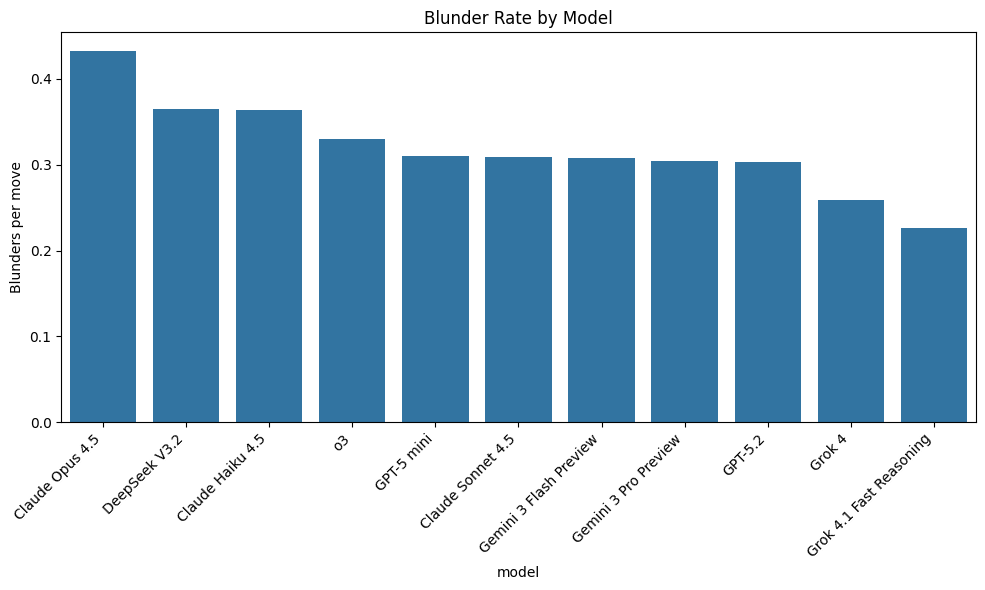

In [24]:
plt.figure(figsize=(10,6))
sns.barplot(x='model', y='blunder_rate', data=df_blunders)
plt.title('Blunder Rate by Model')
plt.ylabel('Blunders per move')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Happy exploring!**     